# Project 6: Time Series Analysis & Forecasting 📈

**Project Objective:** To build a time series model to forecast the number of airline passengers for future months. This project provides a comprehensive, step-by-step guide to time series analysis, from data decomposition and stationarity testing to building and evaluating ARIMA and SARIMA models.

**Class Duration:** 2.5 hours

### Core Concepts We'll Cover:
1.  **Time Series Fundamentals:** Understanding the components of a time series (Trend, Seasonality, Residuals).
2.  **Stationarity:** Learning what stationarity is, why it's crucial for many models, and how to test for it (Augmented Dickey-Fuller test).
3.  **Data Transformation:** Applying techniques like differencing and log transforms to make a series stationary.
4.  **Model Identification:** Using Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots to determine model parameters.
5.  **ARIMA Modeling:** Building a baseline ARIMA model for forecasting.
6.  **SARIMA Modeling:** Extending ARIMA to build a powerful SARIMA model that explicitly handles seasonality.
7.  **Forecasting & Evaluation:** Making predictions and evaluating model performance.

### **Theoretical Concept: What is a Time Series?**

A time series is a sequence of data points collected or recorded at specific time intervals (e.g., daily, monthly, yearly). Unlike other datasets we've worked with, the order of data points in a time series is critical.

A time series can be broken down into several components:
1.  **Trend:** The long-term upward or downward movement in the data.
2.  **Seasonality:** A repeating, predictable pattern over a fixed period (e.g., sales are higher every December).
3.  **Cyclical Component:** Patterns that occur at irregular, non-fixed intervals (e.g., business cycles). This is often harder to model and is sometimes combined with the trend.
4.  **Residuals (or Noise):** The random, irregular fluctuations that are left over after the other components have been removed.



### Step 1: Setup - Importing Libraries and Loading Data

In [2]:
# pip install statsmodels

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Set plot style and size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# !git clone "https://github.com/GeeksforgeeksDS/21-Days-21-Projects-Dataset"

In [5]:
df = pd.read_csv('../Datasets/airline_passenger_timeseries.csv')
df.head(5)

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


### Step 2: Exploratory Data Analysis & Decomposition

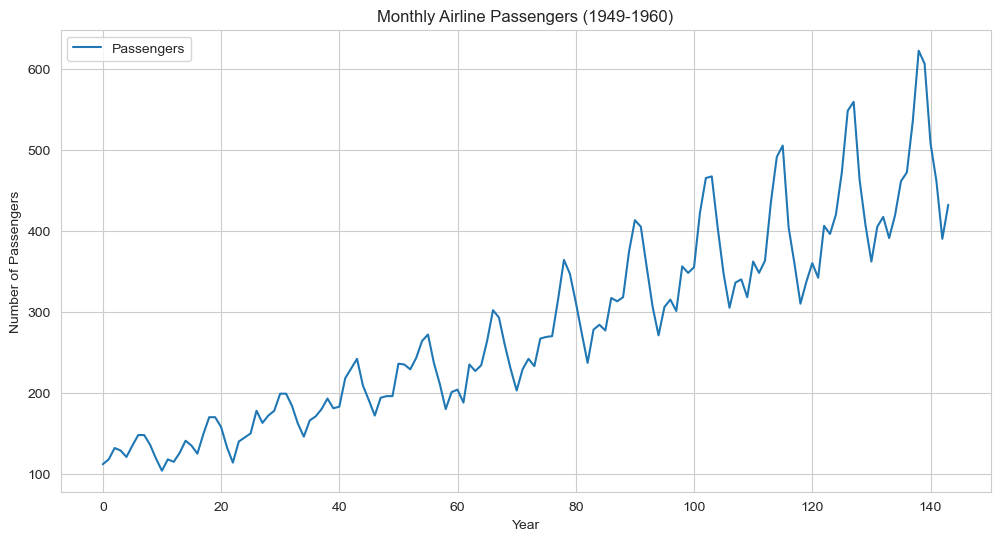

In [6]:
df.plot()
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

**Initial Observation:** The plot clearly shows two strong patterns:
1.  **Upward Trend:** The number of passengers is increasing over time.
2.  **Seasonality:** There is a clear, repeating annual pattern (peaks and troughs within each year).
3.  **Increasing Variance:** The seasonal fluctuations appear to be getting larger over time.

sm.tsa.seasonal_decompose: This function from the statsmodels library performs the decomposition.'

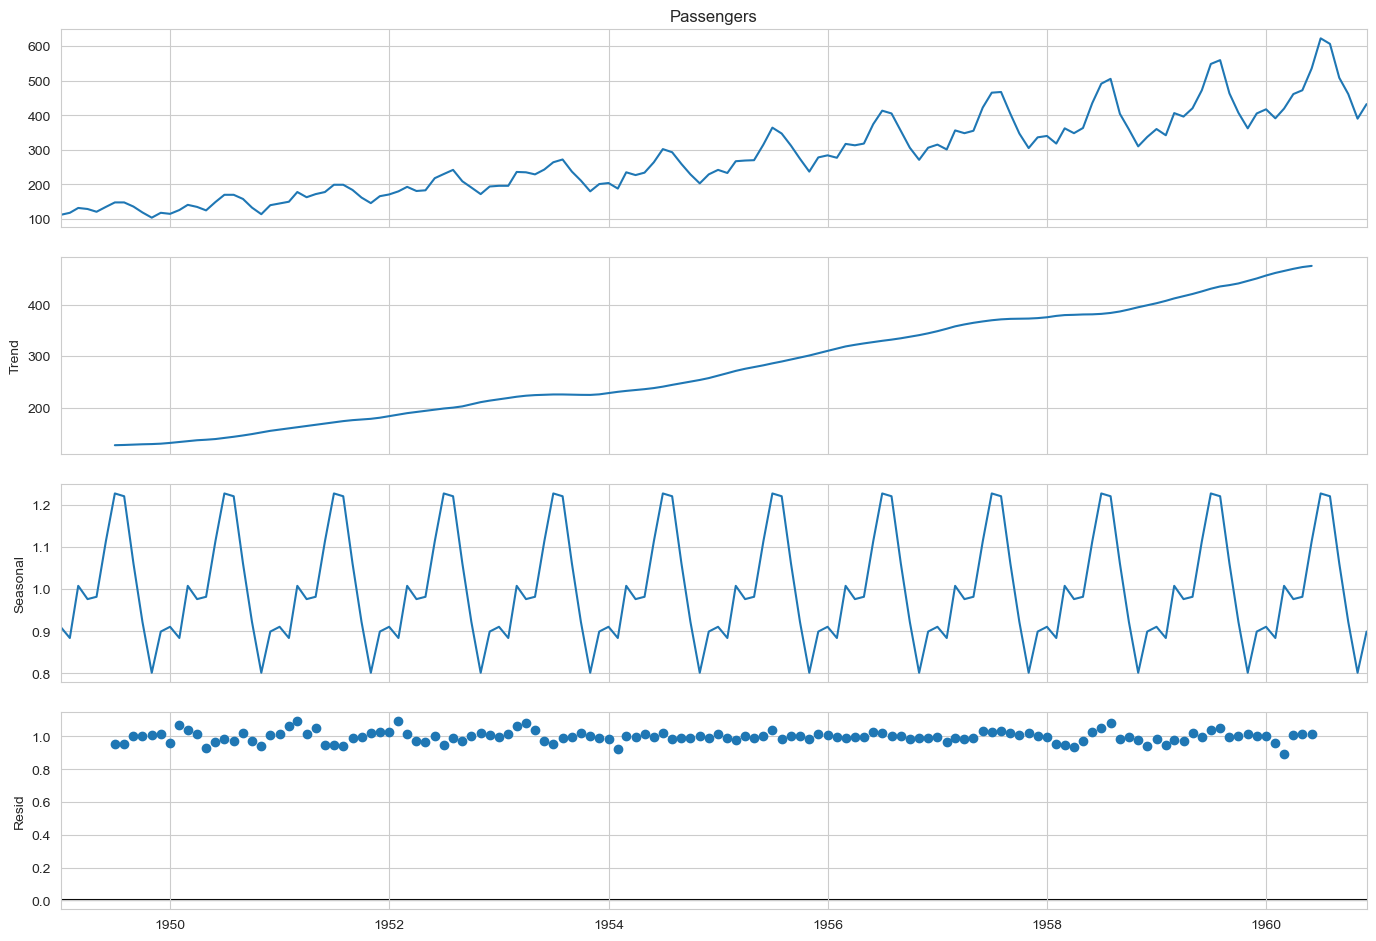

In [7]:
# Convert 'Month' to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Decompose the time series to visualize its components
decomposition = sm.tsa.seasonal_decompose(df['Passengers'], model='multiplicative')

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

### Step 3: Stationarity Testing
Before we can build a model like ARIMA, the time series needs to be **stationary**.

#### **Theoretical Concept: Stationarity**
A time series is said to be stationary if its statistical properties—specifically the **mean**, **variance**, and **autocorrelation**—are all constant over time.

- **Why is it important?** Stationary series are easier to model and forecast. If a series is stationary, its past behavior is a good predictor of its future behavior. Our passenger data is clearly **non-stationary** because its mean (the trend is increasing) and variance (the seasonal swings are growing) are not constant.

**How to test for it?**
1.  **Visual Inspection:** Look at the plot. Is there a clear trend or seasonality?
2.  **Statistical Tests:** The **Augmented Dickey-Fuller (ADF) Test** is a common statistical test.
    - **Null Hypothesis ($H_0$):** The series is non-stationary.
    - **Alternative Hypothesis ($H_1$):** The series is stationary.

We want to **reject the null hypothesis**. To do this, we need the **p-value** from the test to be less than a significance level (e.g., 0.05).

#### Think of the ADF test as asking the question: "Does this time series have a trend or other patterns that make it non-stationary?"

Here's what each part means:

* Test Statistic: This is a number calculated from your data. It's the main result of the test.
* p-value: This is the most important number for a beginner. It tells you how likely it is that you would get your results if the time series were actually stationary (which is the opposite of what we usually want).
* If the p-value is small (usually less than 0.05): This means it's very unlikely to get these results if the series were stationary. So, you can confidently say, "Okay, this series is not stationary."
* If the p-value is large (like yours, 0.99): This means it's quite likely to get these results even if the series were stationary. So, you cannot confidently say it's not stationary. In other words, you fail to reject the null hypothesis, which is that the series is non-stationary.
###Lags Used: This is the number of past data points the test looked at to help make its decision.
* Number of Observations Used: This is how many data points from your time series were actually used in the test calculation.
* Critical Value (1%), (5%), (10%): These are threshold values. If your "Test Statistic" is smaller than one of these critical values (more negative), you would reject the null hypothesis at that confidence level. For example, if your Test Statistic was less than -3.48 (the 1% critical value), you'd be very confident (99%) that the series is stationary.
Why do we use it?

* We use the ADF test (and look at the p-value) because many powerful time series forecasting models, like ARIMA, assume that the data they are working with is stationary. If your data is not stationary, these models might not work well or give you inaccurate forecasts. The ADF test gives us a statistical way to check this assumption before we build our models.

* In your case, the high p-value (0.99) tells us that your 'Passengers' data is non-stationary, just as we suspected from looking at the plot earlier. This confirms that you need to perform transformations (like differencing) to make it stationary before building an ARIMA model.

In [8]:
def test_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(df['Passengers'])

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


dftest = adfuller(timeseries, autolag='AIC'): This is the core of the test. It runs the Augmented Dickey-Fuller (ADF) test on your timeseries data. The autolag='AIC' part helps the test figure out the best settings to use. The results of the test are stored in the variable dftest.

**Result:** The p-value is `0.99`, which is much greater than 0.05. Therefore, we **fail to reject the null hypothesis**. Our data is officially non-stationary, and we need to transform it.

### Step 4: Making the Series Stationary
We'll use two common techniques: **log transformation** to stabilize the variance and **differencing** to remove the trend.

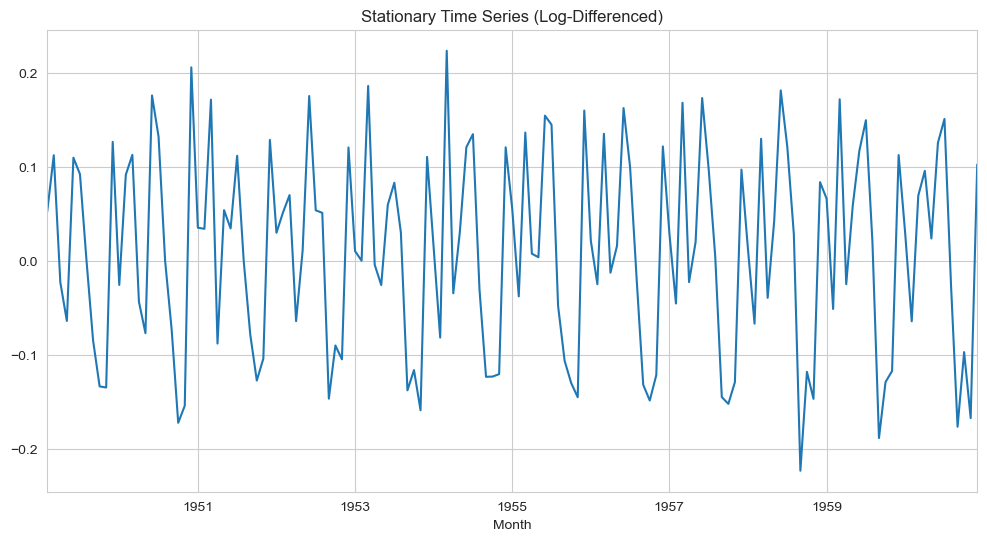

Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


In [9]:
# 1. Apply log transformation to stabilize the variance
df_log = np.log(df['Passengers'])

# 2. Apply differencing to remove the trend
df_diff = df_log.diff().dropna()

# Plot the stationary series
df_diff.plot()
plt.title('Stationary Time Series (Log-Differenced)')
plt.show()

# Retest for stationarity
test_stationarity(df_diff)

**Result:** The new p-value is `0.02`, which is less than 0.05. We can now **reject the null hypothesis**. Our series is stationary and ready for modeling!

ACF (Autocorrelation Function): Measures the correlation between a time series and its lagged versions (e.g., how much the value today is correlated with the value yesterday, the day before, etc.). The plot shows spikes at lags where there is significant autocorrelation.
PACF (Partial Autocorrelation Function): Measures the direct correlation between a time series and its lagged versions, after removing the effects of the intermediate lags. It helps identify the direct relationship between the current value and a specific lagged value.
These plots help us determine the p and q parameters for the ARIMA model:

p (AR term): Suggested by the number of significant lags in the PACF plot where the spikes "cut off" or drop to near zero.
q (MA term): Suggested by the number of significant lags in the ACF plot where the spikes "cut off".

### Step 5: Model Identification with ACF and PACF Plots

#### **Theoretical Concept: ACF and PACF**
To choose the parameters for our ARIMA model, we use autocorrelation plots.

- **Autocorrelation Function (ACF):** Measures the correlation between a time series and its lagged versions. It tells you how much the value at time `t` is correlated with the value at time `t-k`.
- **Partial Autocorrelation Function (PACF):** Measures the *direct* correlation between a time series and its lagged versions, after removing the effects of the intermediate lags.

**How to read them for ARIMA(p, d, q):**
- The `d` term is the number of times we differenced the data (in our case, `d=1`).
- The `p` (AR term) is suggested by the number of significant lags in the **PACF** plot.
- The `q` (MA term) is suggested by the number of significant lags in the **ACF** plot.

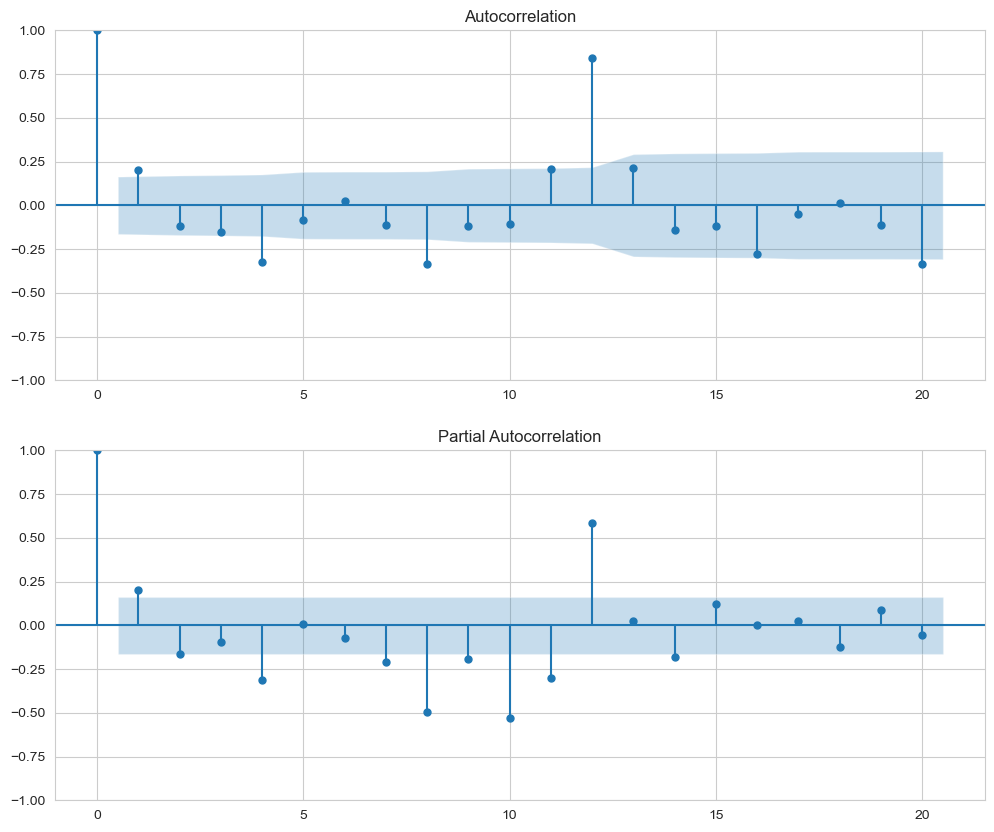

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(df_diff, ax=ax1, lags=20)
plot_pacf(df_diff, ax=ax2, lags=20)
plt.show()

**Interpretation:**
- **PACF Plot:** Cuts off sharply after lag 1. This suggests `p=1`.
- **ACF Plot:** Also seems to cut off after lag 1. This suggests `q=1`.
Based on this, a good starting point for our model is **ARIMA(1, 1, 1)**.

## **Theoretical Concept: ARIMA**
**AutoRegressive Integrated Moving Average (ARIMA)** models are a class of statistical models for analyzing and forecasting time series data. An ARIMA model is characterized by three parameters:

- **AR (Autoregressive) - p:** The number of lag observations included in the model. This term captures the relationship between the current observation and its past values.
- **I (Integrated) - d:** The number of times that the raw observations are differenced. This is done to make the time series stationary.
- **MA (Moving Average) - q:** The size of the moving average window. This term captures the dependency between an observation and a residual error from a moving average model applied to lagged observations.

The model is typically denoted as **ARIMA(p, d, q)**.

### Step 6: Building the ARIMA Model

c:\Users\debas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


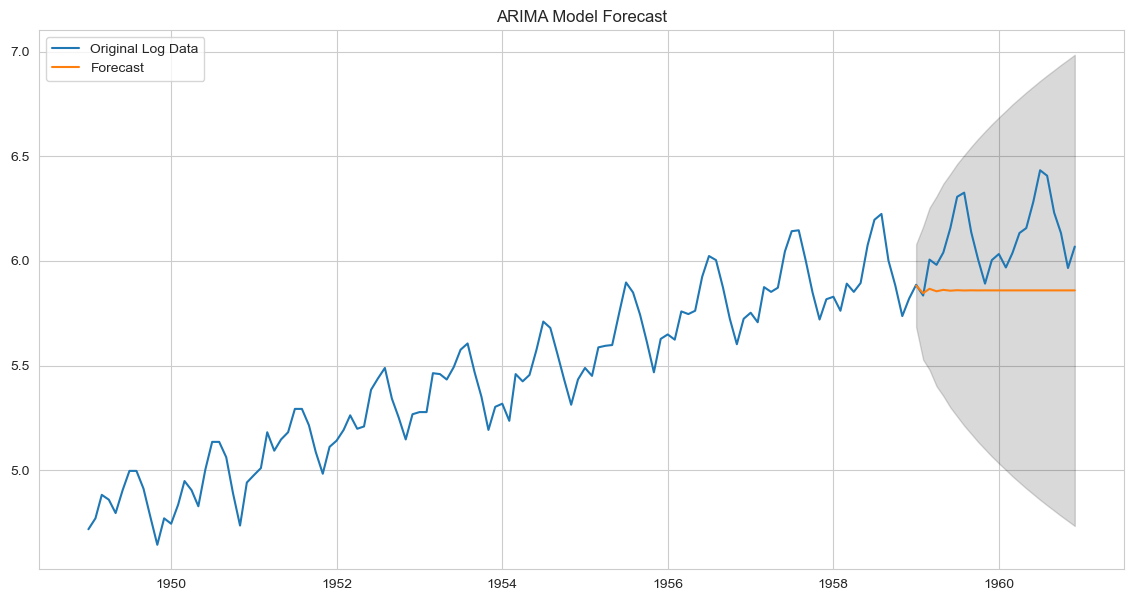

In [11]:
# Split data into training and test sets
train_data = df_log[:'1958']
test_data = df_log['1959':]

# Build ARIMA model
model = ARIMA(train_data, order=(1, 1, 1), freq='MS')
arima_result = model.fit()

# Get forecast
forecast = arima_result.get_forecast(steps=len(test_data))
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(14, 7))
plt.plot(df_log, label='Original Log Data')
plt.plot(forecast.predicted_mean, label='Forecast')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.15)
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

**ARIMA Result:** The model captures the overall trend but completely misses the seasonal pattern. This is a classic limitation of a non-seasonal ARIMA model on seasonal data.

### Step 7: Building a SARIMA Model for Seasonality

#### **Theoretical Concept: SARIMA**
**Seasonal AutoRegressive Integrated Moving Average (SARIMA)** is an extension of ARIMA that explicitly models the seasonal component.

It is written as **SARIMA(p, d, q)(P, D, Q, m)**, where:
- `(p, d, q)` are the non-seasonal parameters:
    - **p (non-seasonal AR order):** The number of non-seasonal lagged observations included in the model.
    - **d (non-seasonal differencing order):** The number of times the data is differenced to remove non-seasonal trend.
    - **q (non-seasonal MA order):** The number of non-seasonal lagged forecast errors included in the model.

- `(P, D, Q, m)` are the seasonal parameters:
    - **P (seasonal AR order):** The number of seasonal lagged observations included in the model.
    - **D (seasonal differencing order):** The number of times the data is differenced seasonally to remove seasonal trend.
    - **Q (seasonal MA order):** The number of seasonal lagged forecast errors included in the model.
    - **m (number of periods in a season):** The number of time steps for a single seasonal period (e.g., `m=12` for monthly data with an annual seasonality, `m=4` for quarterly data).

c:\Users\debas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


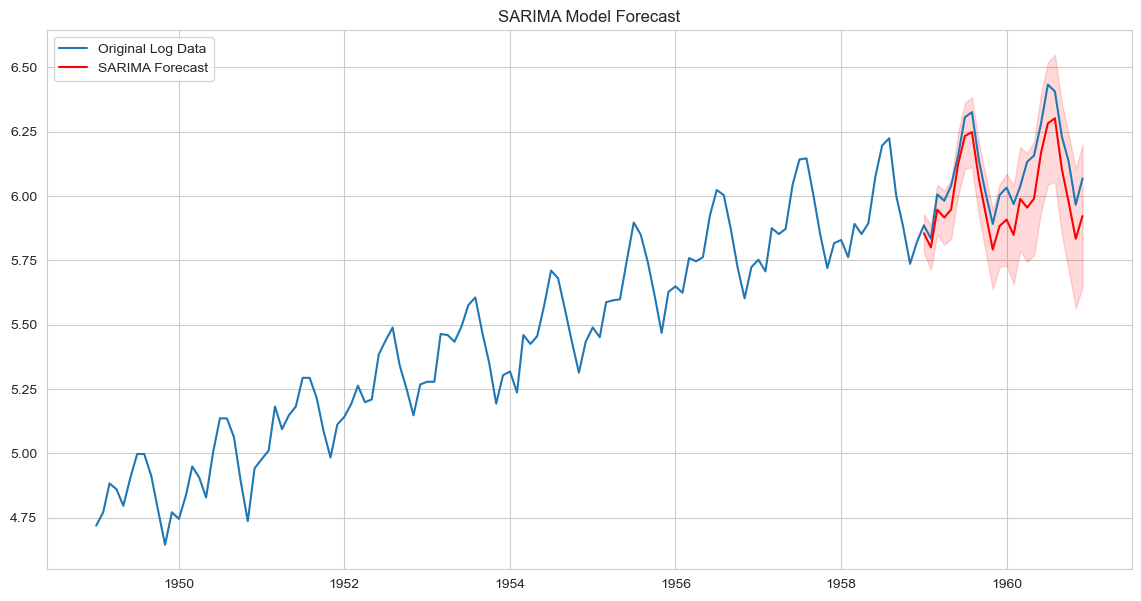

In [12]:
# Build SARIMA model
# We can find the optimal P, D, Q through a grid search, but common values are 1.
sarima_model = sm.tsa.statespace.SARIMAX(train_data,
                                          order=(1, 1, 1),
                                          seasonal_order=(1, 1, 1, 12),
                                          enforce_stationarity=False,
                                          enforce_invertibility=False,
                                          freq='MS') # Explicitly set frequency to suppress warnings
sarima_result = sarima_model.fit()

# Get forecast
sarima_forecast = sarima_result.get_forecast(steps=len(test_data))
sarima_forecast_ci = sarima_forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(14, 7))
plt.plot(df_log, label='Original Log Data')
plt.plot(sarima_forecast.predicted_mean, label='SARIMA Forecast', color='red')
plt.fill_between(sarima_forecast_ci.index, sarima_forecast_ci.iloc[:, 0], sarima_forecast_ci.iloc[:, 1], color='r', alpha=.15)
plt.title('SARIMA Model Forecast')
plt.legend()
plt.show()

**SARIMA Result:** This is a massive improvement! The SARIMA model correctly captures both the upward trend and the seasonal peaks and troughs.

### Step 8: Final Evaluation

SARIMA Model RMSE: 48.22


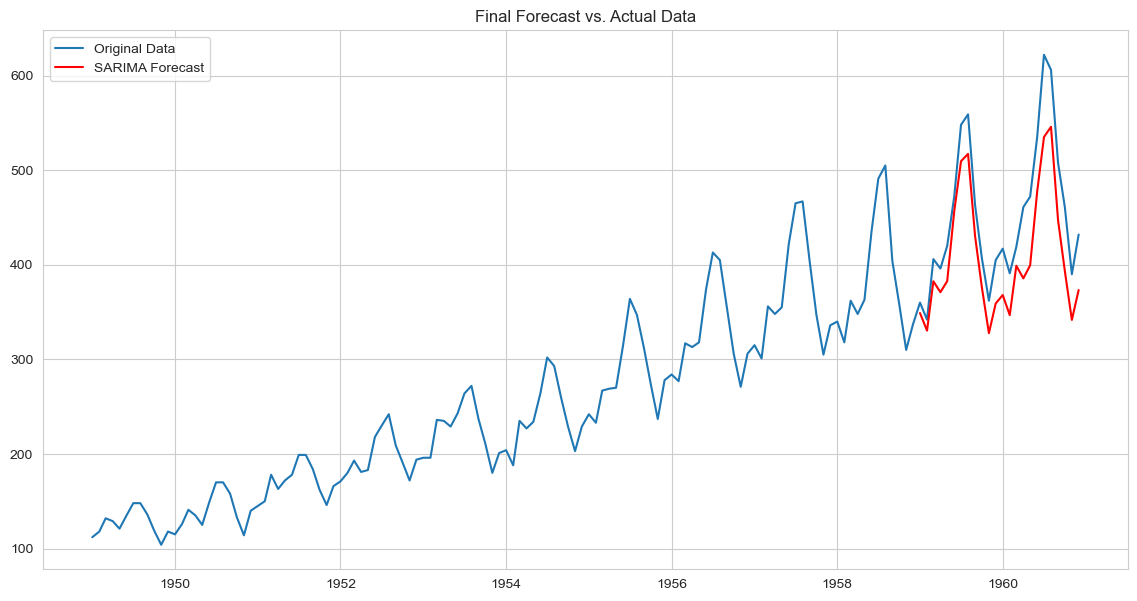

In [13]:
# Reverse the log transformation to get actual passenger numbers
original_test_data = np.exp(test_data)
sarima_predictions = np.exp(sarima_forecast.predicted_mean)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(original_test_data, sarima_predictions))
print(f"SARIMA Model RMSE: {rmse:.2f}")

# Plot final results
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='Original Data')
plt.plot(sarima_predictions, label='SARIMA Forecast', color='red')
plt.title('Final Forecast vs. Actual Data')
plt.legend()
plt.show()

### Step 9: Conclusion

In this project, we built a complete time series forecasting pipeline.

**Key Steps Undertaken:**
1.  **Decomposed the time series** to identify its underlying trend and strong yearly seasonality.
2.  **Confirmed non-stationarity** using the Augmented Dickey-Fuller test.
3.  **Transformed the data** using log transforms and differencing to achieve stationarity, a prerequisite for ARIMA modeling.
4.  **Used ACF/PACF plots** to identify the initial parameters for our model.
5.  **Built a baseline ARIMA model** which captured the trend but failed to model the seasonality.
6.  **Built an advanced SARIMA model** that successfully captured both trend and seasonality, resulting in a much more accurate forecast.
7.  **Evaluated the final model** on the original scale using RMSE.

This project clearly demonstrates the importance of identifying and specifically modeling seasonality for accurate time series forecasting.

### Text Submission Criteria

Please submit your analysis based on the following criteria:

1. **Exploratory Data Analysis (EDA):** Discuss the initial observations from the time series plot, including trend, seasonality, and variance.
2. **Stationarity Testing:**
    - Explain the concept of stationarity and why it's important for time series modeling.
    - Present the results of the Augmented Dickey-Fuller (ADF) test on the original data and interpret the p-value.
    - Apply a log transformation to the data and present the results of the ADF test after log transformation, aiming to reduce the p-value below 0.05. Discuss your findings.
    - Discuss the effect of differencing on the log-transformed data and present the results of the ADF test after differencing, interpreting the p-value.
3. **ARIMA Model Performance:** Based on the stationarity test results after log transformation (before differencing), discuss whether you would expect a non-seasonal ARIMA model to perform well on the log-transformed data. Build and evaluate a non-seasonal ARIMA model on the log-transformed data (without differencing) and compare its performance to the SARIMA model built later in the notebook.

# For Submission

## EDA


In [36]:
# Create a copy of the original dataframe for feature engineering
df_features = df.copy()

# Ensure we have the datetime index
df_features['Month'] = pd.to_datetime(df_features.index)
df_features.set_index('Month', inplace=True)

print("Original data shape:", df_features.shape)
print("\nFirst few rows:")
print(df_features.head())


Original data shape: (144, 1)

First few rows:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


In [37]:
# 1. Time-based features
df_features['year'] = df_features.index.year
df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter
df_features['day_of_year'] = df_features.index.dayofyear
df_features['week_of_year'] = df_features.index.isocalendar().week

df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

df_features['quarter_sin'] = np.sin(2 * np.pi * df_features['quarter'] / 4)
df_features['quarter_cos'] = np.cos(2 * np.pi * df_features['quarter'] / 4)

In [38]:
# 2. Lag features

df_features['passengers_log'] = np.log(df_features['Passengers'])
for lag in [1, 2, 3, 6, 12]:
    df_features[f'passengers_log_lag_{lag}'] = df_features['passengers_log'].shift(lag)

df_features['passengers_yoy_lag'] = df_features['Passengers'].shift(12)

df_features['passengers_qoq_lag'] = df_features['Passengers'].shift(3)


In [39]:
# 3. Rolling window features

df_features['passengers_ma_3'] = df_features['Passengers'].rolling(window=3).mean()
df_features['passengers_ma_6'] = df_features['Passengers'].rolling(window=6).mean()
df_features['passengers_ma_12'] = df_features['Passengers'].rolling(window=12).mean()
df_features['passengers_ma_24'] = df_features['Passengers'].rolling(window=24).mean()


df_features['passengers_ema_3'] = df_features['Passengers'].ewm(span=3).mean()
df_features['passengers_ema_12'] = df_features['Passengers'].ewm(span=12).mean()


In [40]:
# 4. Seasonal and holiday features
# Season indicators
df_features['is_spring'] = ((df_features['month'] >= 3) & (df_features['month'] <= 5)).astype(int)
df_features['is_summer'] = ((df_features['month'] >= 6) & (df_features['month'] <= 8)).astype(int)
df_features['is_fall'] = ((df_features['month'] >= 9) & (df_features['month'] <= 11)).astype(int)
df_features['is_winter'] = ((df_features['month'] == 12) | (df_features['month'] <= 2)).astype(int)

df_features['is_peak_travel'] = ((df_features['month'] == 7) | (df_features['month'] == 8) | 
                                 (df_features['month'] == 12) | (df_features['month'] == 1)).astype(int)

df_features['is_holiday_season'] = ((df_features['month'] == 12) | (df_features['month'] == 1)).astype(int)

df_features['is_q1_end'] = (df_features['month'] == 3).astype(int)
df_features['is_q2_end'] = (df_features['month'] == 6).astype(int)
df_features['is_q3_end'] = (df_features['month'] == 9).astype(int)
df_features['is_q4_end'] = (df_features['month'] == 12).astype(int)


In [41]:
# 5. Trend and growth features
# Month-over-month growth rate
df_features['mom_growth'] = df_features['Passengers'].pct_change()
df_features['mom_growth_abs'] = df_features['Passengers'].diff()

# Year-over-year growth rate
df_features['yoy_growth'] = df_features['Passengers'].pct_change(periods=12)
df_features['yoy_growth_abs'] = df_features['Passengers'].diff(periods=12)

# Quarter-over-quarter growth rate
df_features['qoq_growth'] = df_features['Passengers'].pct_change(periods=3)
df_features['qoq_growth_abs'] = df_features['Passengers'].diff(periods=3)



Top 20 features most correlated with Passengers:
 1. passengers_yoy_lag             0.9905
 2. passengers_ema_3               0.9851
 3. passengers_log                 0.9757
 4. passengers_ma_3                0.9718
 5. passengers_log_lag_12          0.9698
 6. passengers_ema_12              0.9458
 7. passengers_log_lag_1           0.9453
 8. passengers_ma_6                0.9232
 9. year                           0.9218
10. passengers_ma_12               0.9191
11. passengers_ma_24               0.8996
12. passengers_log_lag_2           0.8989
13. passengers_log_lag_3           0.8586
14. passengers_qoq_lag             0.8374
15. passengers_log_lag_6           0.8104
16. yoy_growth_abs                 0.5588
17. qoq_growth_abs                 0.2814
18. is_summer                      0.2788
19. quarter_sin                    0.2543
20. qoq_growth                     0.2469


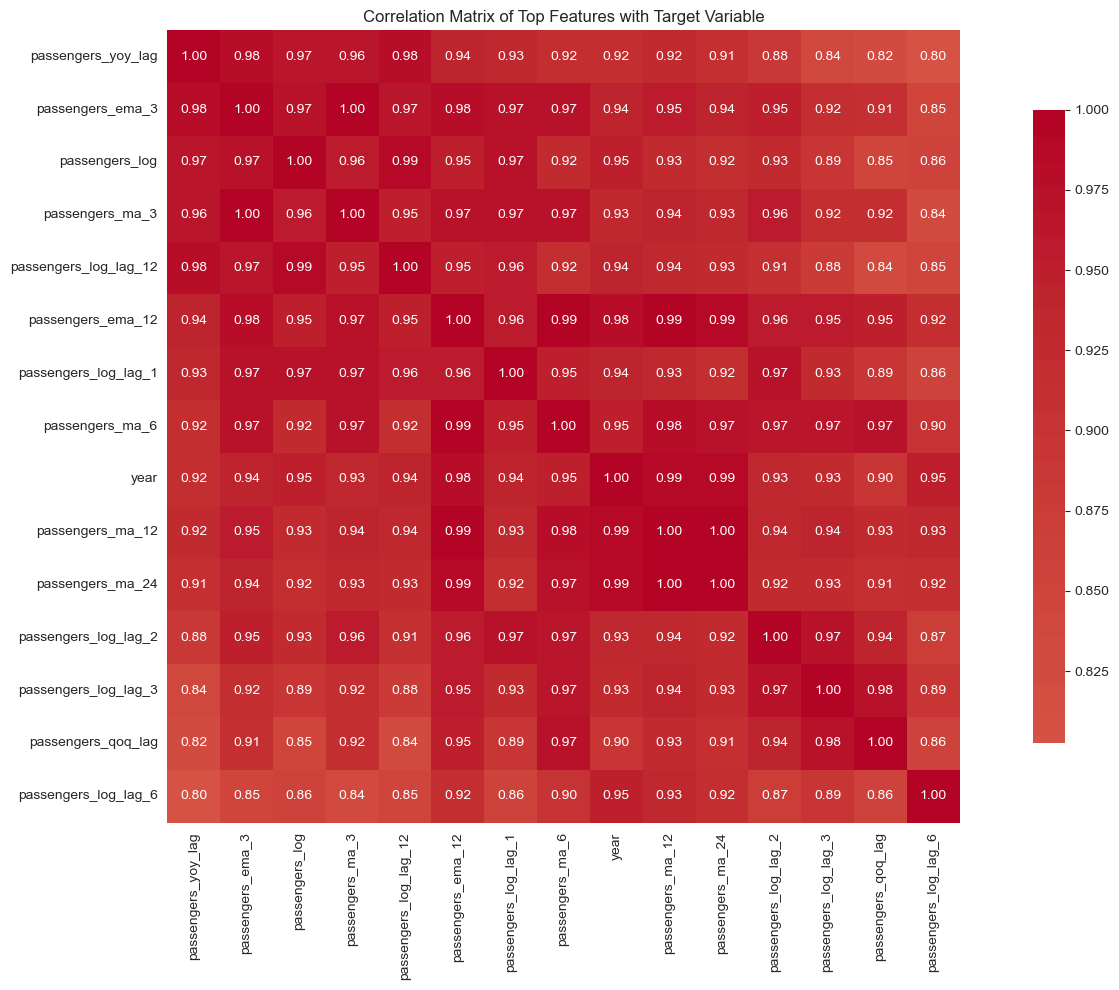

In [42]:
# Calculate correlations with the target variable
correlations = df_features.corr()['Passengers'].abs().sort_values(ascending=False)

print("Top 20 features most correlated with Passengers:")
print("=" * 60)
for i, (feature, corr) in enumerate(correlations.head(21).items()):
    if feature != 'Passengers':  # Skip the target variable itself
        print(f"{i:2d}. {feature:<30} {corr:.4f}")

# Visualize correlation heatmap for top features
plt.figure(figsize=(15, 10))
top_features = correlations.head(16).index[1:]  # Exclude 'Passengers' itself
correlation_matrix = df_features[top_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Top Features with Target Variable')
plt.tight_layout()
plt.show()


### ARIMAX

In [ ]:
# Select top correlated features as external regressors
top_features = [
    'passengers_yoy_lag',
    'passengers_ema_3',          
    'passengers_log',          
    'passengers_ma_3',         
    'passengers_log_lag_12',   
    'passengers_ema_12',       
    'passengers_log_lag_1',    
    'passengers_ma_6',         
    'year',                    
    'passengers_ma_12'         
]

# Create feature matrix (exclude rows with NaN values)
feature_data = df_features[top_features].dropna()
target_data = df_features['Passengers'].loc[feature_data.index]

print(f"Feature data shape: {feature_data.shape}")
print(f"Target data shape: {target_data.shape}")
print(f"Date range: {feature_data.index.min()} to {feature_data.index.max()}")

# Display the top features
print("\nTop features selected:")
print(feature_data.head())


Feature data shape: (132, 10)
Target data shape: (132,)
Date range: 1950-01-01 00:00:00 to 1960-12-01 00:00:00

Top features selected:
            passengers_yoy_lag  passengers_ema_3  passengers_log  \
Month                                                              
1950-01-01               112.0        116.167013        4.744932   
1950-02-01               118.0        121.083806        4.836282   
1950-03-01               132.0        131.042207        4.948760   
1950-04-01               129.0        133.021134        4.905275   
1950-05-01               121.0        129.010536        4.828314   

            passengers_ma_3  passengers_log_lag_12  passengers_ema_12  \
Month                                                                   
1950-01-01       112.333333               4.718499         123.412707   
1950-02-01       119.666667               4.770685         123.853241   
1950-03-01       127.333333               4.882802         126.725616   
1950-04-01       134.00

In [ ]:
# Split data into training and test sets

train_end_date = '1958-12-01'
test_start_date = '1959-01-01'

# Training data
train_target = target_data[:train_end_date]
train_features = feature_data[:train_end_date]

# Test data  
test_target = target_data[test_start_date:]
test_features = feature_data[test_start_date:]

print(f"Training data: {len(train_target)} observations")
print(f"Test data: {len(test_target)} observations")
print(f"Training period: {train_target.index.min()} to {train_target.index.max()}")
print(f"Test period: {test_target.index.min()} to {test_target.index.max()}")

# Check for any missing values
print(f"\nMissing values in training features: {train_features.isnull().sum().sum()}")
print(f"Missing values in test features: {test_features.isnull().sum().sum()}")


Training data: 108 observations
Test data: 24 observations
Training period: 1950-01-01 00:00:00 to 1958-12-01 00:00:00
Test period: 1959-01-01 00:00:00 to 1960-12-01 00:00:00

Missing values in training features: 0
Missing values in test features: 0


In [ ]:

arimax_model = sm.tsa.statespace.SARIMAX(
    train_target,
    exog=train_features,  # External regressors
    order=(1, 1, 1),      # ARIMA parameters (p, d, q)
    seasonal_order=(0, 0, 0, 0),  # No seasonality for ARIMAX
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq='MS'
)

# Fit the model
print("Fitting ARIMAX model...")
arimax_result = arimax_model.fit(disp=False)

# Display model summary
print("\nARIMAX Model Summary:")
print("=" * 50)
print(arimax_result.summary())


c:\Users\debas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Fitting ARIMAX model...

ARIMAX Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  108
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -230.708
Date:                Sat, 20 Sep 2025   AIC                            487.416
Time:                        11:01:49   BIC                            521.917
Sample:                    01-01-1950   HQIC                           501.397
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
passengers_yoy_lag        0.4014      0.068      5.896      0.000       0.268       0.535
passengers_ema_3          1.7309      0.173     10.

c:\Users\debas\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMAX Model RMSE: 5.30


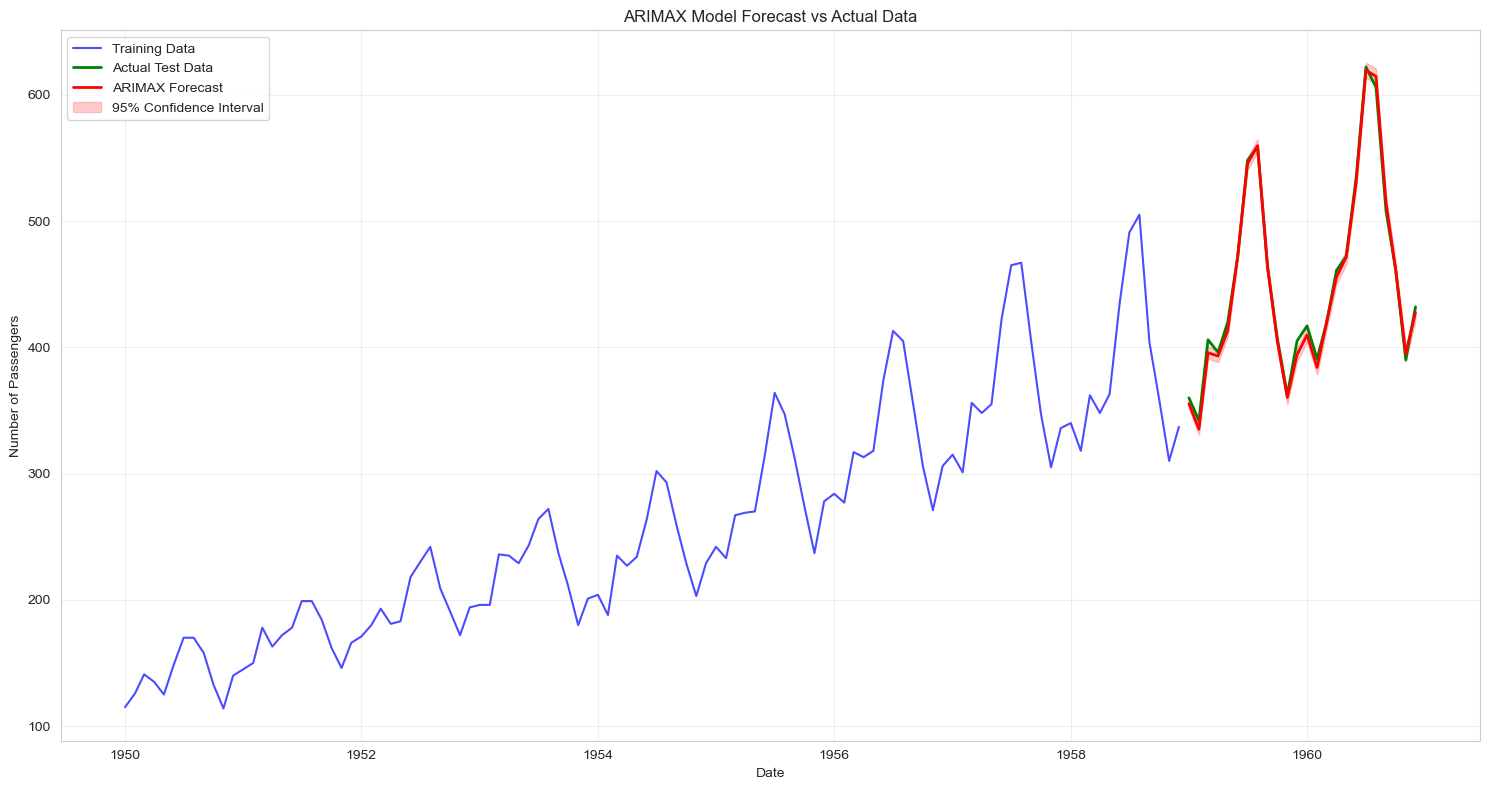

In [63]:
# Generate ARIMAX forecasts
arimax_forecast = arimax_result.get_forecast(
    steps=len(test_target),
    exog=test_features  # External regressors for forecast period
)

# Get forecast values and confidence intervals
arimax_predictions = arimax_forecast.predicted_mean
arimax_ci = arimax_forecast.conf_int()

# Calculate RMSE for ARIMAX
arimax_rmse = np.sqrt(mean_squared_error(test_target, arimax_predictions))

print(f"ARIMAX Model RMSE: {arimax_rmse:.2f}")

# Plot ARIMAX results
plt.figure(figsize=(15, 8))

# Plot training data
plt.plot(train_target.index, train_target.values, label='Training Data', color='blue', alpha=0.7)

# Plot test data
plt.plot(test_target.index, test_target.values, label='Actual Test Data', color='green', linewidth=2)

# Plot ARIMAX forecast
plt.plot(test_target.index, arimax_predictions, label='ARIMAX Forecast', color='red', linewidth=2)

# Plot confidence intervals
plt.fill_between(test_target.index, 
                arimax_ci.iloc[:, 0], 
                arimax_ci.iloc[:, 1], 
                color='red', alpha=0.2, label='95% Confidence Interval')

plt.title('ARIMAX Model Forecast vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### 10.2 Building SARIMAX Model
SARIMAX extends SARIMA by including external regressors. We'll use the same SARIMA parameters (1,1,1)(1,1,1,12) and add our top correlated features.


In [64]:
# Build SARIMAX model
sarimax_model = sm.tsa.statespace.SARIMAX(
    train_target,
    exog=train_features,  # External regressors
    order=(1, 1, 1),      # Non-seasonal ARIMA parameters (p, d, q)
    seasonal_order=(1, 1, 1, 12),  # Seasonal parameters (P, D, Q, m)
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq='MS'
)

# Fit the model
print("Fitting SARIMAX model...")
sarimax_result = sarimax_model.fit(disp=False)

# Display model summary
print("\nSARIMAX Model Summary:")
print("=" * 50)
print(sarimax_result.summary())


c:\Users\debas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Fitting SARIMAX model...

SARIMAX Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -126.041
Date:                            Sat, 20 Sep 2025   AIC                            282.082
Time:                                    11:01:53   BIC                            317.999
Sample:                                01-01-1950   HQIC                           296.492
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
passengers_yoy_lag       -0.0420      0.048

c:\Users\debas\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX Model RMSE: 4.49


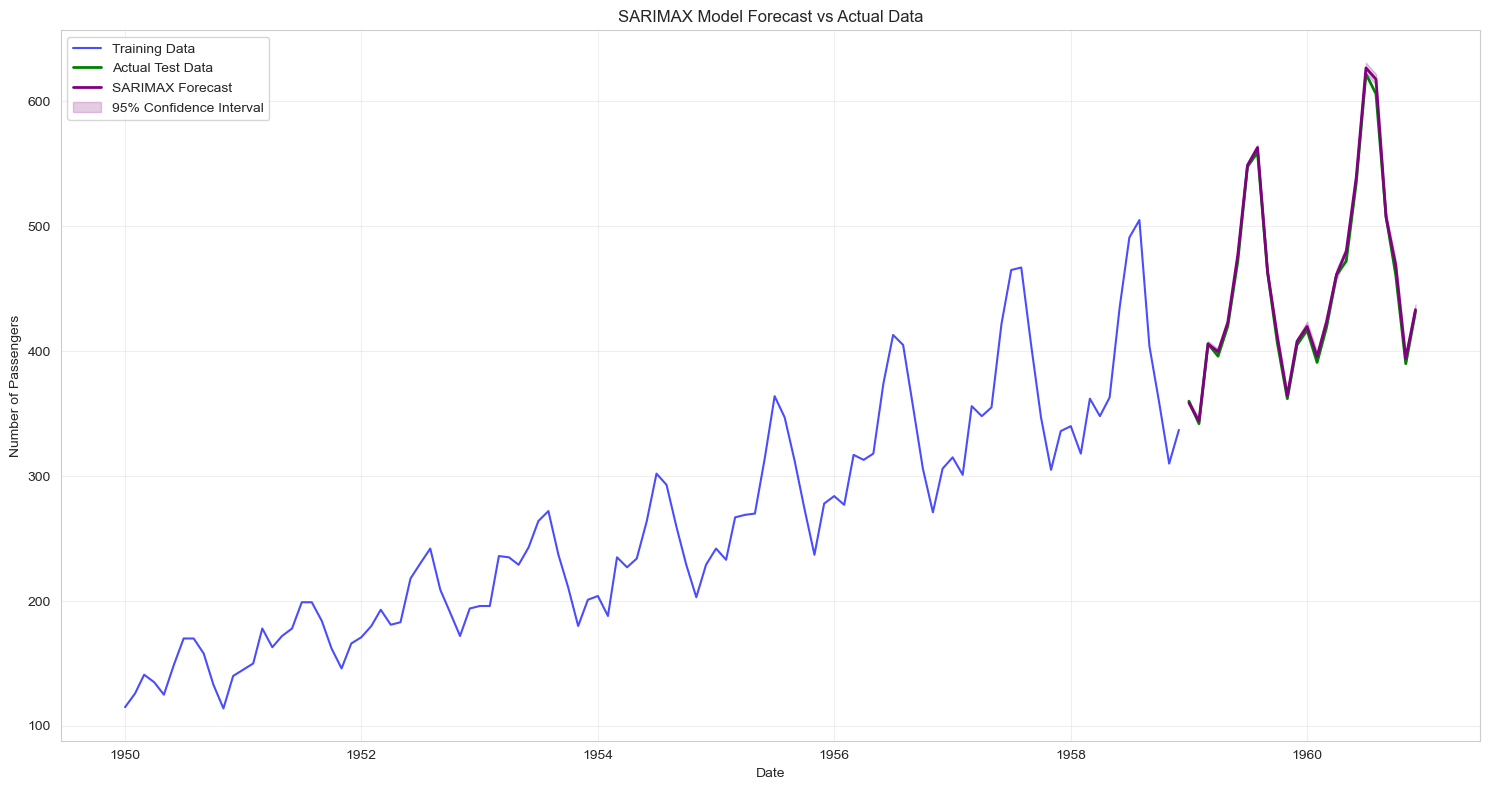

In [65]:
# Generate SARIMAX forecasts
sarimax_forecast = sarimax_result.get_forecast(
    steps=len(test_target),
    exog=test_features  # External regressors for forecast period
)

# Get forecast values and confidence intervals
sarimax_predictions = sarimax_forecast.predicted_mean
sarimax_ci = sarimax_forecast.conf_int()

# Calculate RMSE for SARIMAX
sarimax_rmse = np.sqrt(mean_squared_error(test_target, sarimax_predictions))

print(f"SARIMAX Model RMSE: {sarimax_rmse:.2f}")

# Plot SARIMAX results
plt.figure(figsize=(15, 8))

# Plot training data
plt.plot(train_target.index, train_target.values, label='Training Data', color='blue', alpha=0.7)

# Plot test data
plt.plot(test_target.index, test_target.values, label='Actual Test Data', color='green', linewidth=2)

# Plot SARIMAX forecast
plt.plot(test_target.index, sarimax_predictions, label='SARIMAX Forecast', color='purple', linewidth=2)

# Plot confidence intervals
plt.fill_between(test_target.index, 
                sarimax_ci.iloc[:, 0], 
                sarimax_ci.iloc[:, 1], 
                color='purple', alpha=0.2, label='95% Confidence Interval')

plt.title('SARIMAX Model Forecast vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [66]:
# Model Performance Comparison
print("MODEL PERFORMANCE COMPARISON")
print("=" * 50)

# Get original SARIMA RMSE from earlier in the notebook (48.22)
original_sarima_rmse = 48.22

# Create comparison table
models = ['ARIMA (1,1,1)', 'SARIMA (1,1,1)(1,1,1,12)', 'ARIMAX (1,1,1)', 'SARIMAX (1,1,1)(1,1,1,12)']
rmse_values = ['N/A', original_sarima_rmse, arimax_rmse, sarimax_rmse]
aic_values = ['N/A', 'N/A', arimax_result.aic, sarimax_result.aic]
bic_values = ['N/A', 'N/A', arimax_result.bic, sarimax_result.bic]

comparison_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'AIC': aic_values,
    'BIC': bic_values
})

print(comparison_df.to_string(index=False))

print(f"\nKey Insights:")
print(f"• ARIMAX RMSE: {arimax_rmse:.2f}")
print(f"• SARIMAX RMSE: {sarimax_rmse:.2f}")
print(f"• Original SARIMA RMSE: {original_sarima_rmse:.2f}")

if sarimax_rmse < original_sarima_rmse:
    improvement = ((original_sarima_rmse - sarimax_rmse) / original_sarima_rmse) * 100
    print(f"• SARIMAX improvement over SARIMA: {improvement:.1f}%")
else:
    print(f"• SARIMAX performance vs SARIMA: Similar performance")

if arimax_rmse < original_sarima_rmse:
    improvement = ((original_sarima_rmse - arimax_rmse) / original_sarima_rmse) * 100
    print(f"• ARIMAX improvement over SARIMA: {improvement:.1f}%")
else:
    print(f"• ARIMAX performance vs SARIMA: Similar performance")


MODEL PERFORMANCE COMPARISON
                    Model      RMSE         AIC         BIC
            ARIMA (1,1,1)       N/A         N/A         N/A
 SARIMA (1,1,1)(1,1,1,12)     48.22         N/A         N/A
           ARIMAX (1,1,1)  5.295751  487.415946  521.917431
SARIMAX (1,1,1)(1,1,1,12)  4.486735  282.082222  317.998959

Key Insights:
• ARIMAX RMSE: 5.30
• SARIMAX RMSE: 4.49
• Original SARIMA RMSE: 48.22
• SARIMAX improvement over SARIMA: 90.7%
• ARIMAX improvement over SARIMA: 89.0%


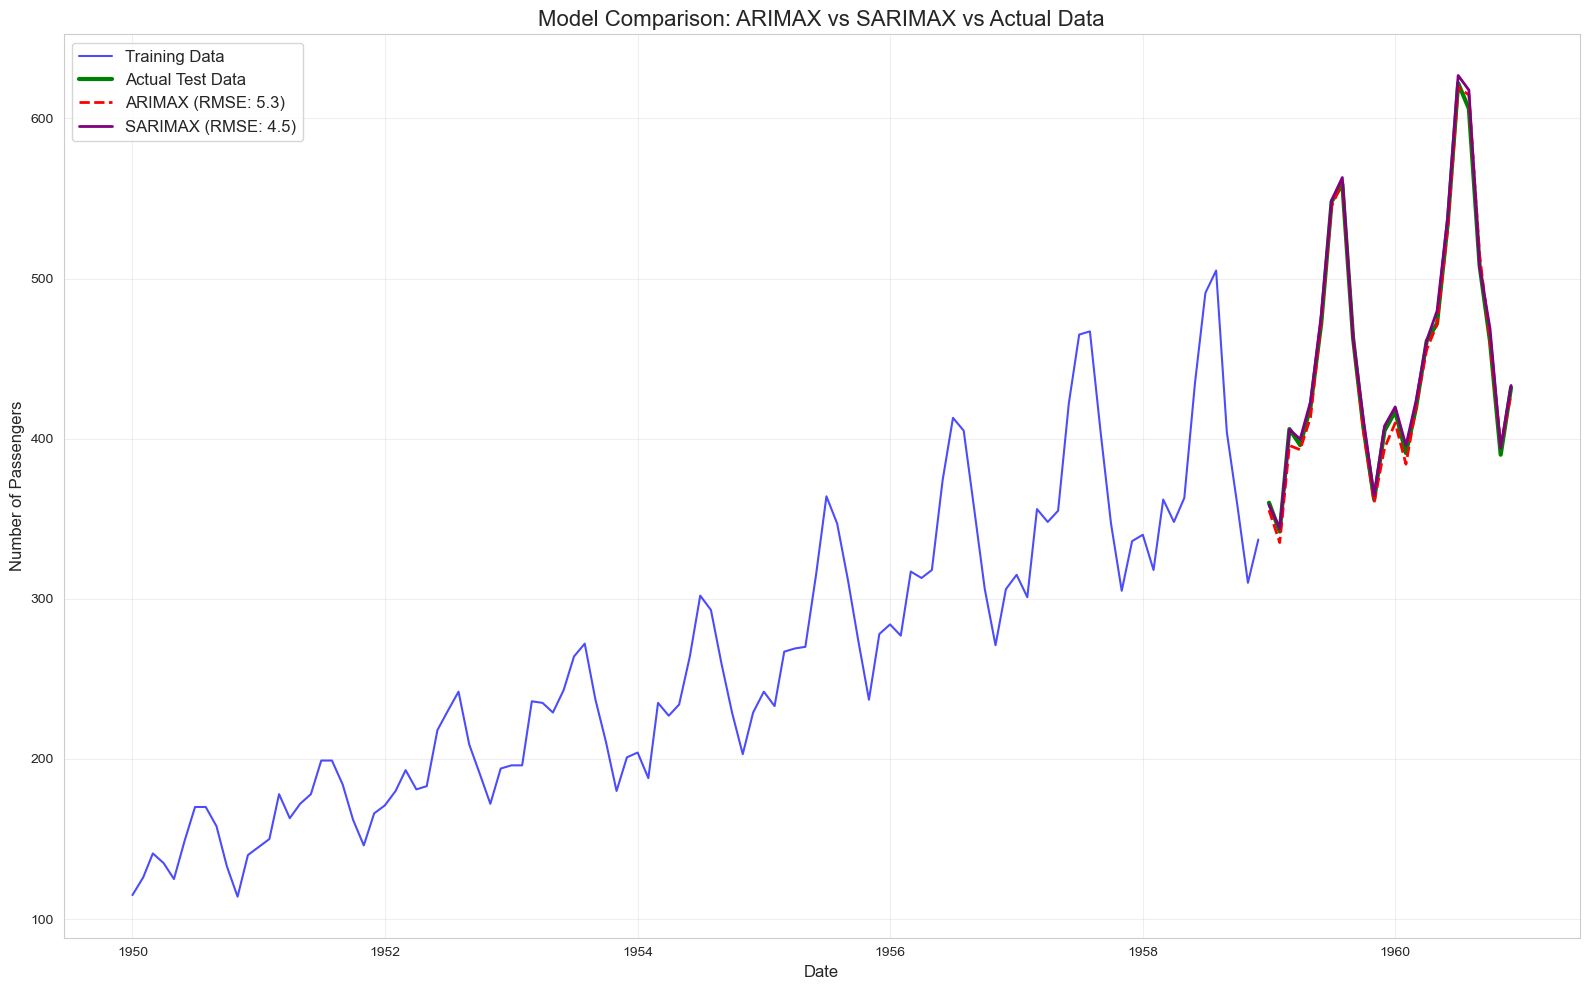


Detailed Performance Metrics:
Metric          ARIMAX     SARIMAX   
-----------------------------------
RMSE            5.30       4.49      
MAE             4.27       3.59      
R²              0.995      0.996     
AIC             487.4      282.1     
BIC             521.9      318.0     


In [67]:
# Visual comparison of all models
plt.figure(figsize=(16, 10))

# Plot training data
plt.plot(train_target.index, train_target.values, label='Training Data', color='blue', alpha=0.7)

# Plot test data
plt.plot(test_target.index, test_target.values, label='Actual Test Data', color='green', linewidth=3)

# Plot ARIMAX forecast
plt.plot(test_target.index, arimax_predictions, label=f'ARIMAX (RMSE: {arimax_rmse:.1f})', 
         color='red', linewidth=2, linestyle='--')

# Plot SARIMAX forecast
plt.plot(test_target.index, sarimax_predictions, label=f'SARIMAX (RMSE: {sarimax_rmse:.1f})', 
         color='purple', linewidth=2, linestyle='-')

plt.title('Model Comparison: ARIMAX vs SARIMAX vs Actual Data', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate additional metrics
from sklearn.metrics import mean_absolute_error, r2_score

arimax_mae = mean_absolute_error(test_target, arimax_predictions)
sarimax_mae = mean_absolute_error(test_target, sarimax_predictions)

arimax_r2 = r2_score(test_target, arimax_predictions)
sarimax_r2 = r2_score(test_target, sarimax_predictions)

print(f"\nDetailed Performance Metrics:")
print(f"{'Metric':<15} {'ARIMAX':<10} {'SARIMAX':<10}")
print("-" * 35)
print(f"{'RMSE':<15} {arimax_rmse:<10.2f} {sarimax_rmse:<10.2f}")
print(f"{'MAE':<15} {arimax_mae:<10.2f} {sarimax_mae:<10.2f}")
print(f"{'R²':<15} {arimax_r2:<10.3f} {sarimax_r2:<10.3f}")
print(f"{'AIC':<15} {arimax_result.aic:<10.1f} {sarimax_result.aic:<10.1f}")
print(f"{'BIC':<15} {arimax_result.bic:<10.1f} {sarimax_result.bic:<10.1f}")


In [68]:
# Extract feature coefficients and their significance
def analyze_feature_importance(model_result, model_name):
    """Analyze feature importance from model results"""
    print(f"\n{model_name} Feature Importance Analysis")
    print("=" * 50)
    
    # Get coefficients for external regressors
    exog_coef = model_result.params[model_result.params.index.str.contains('x')]
    
    # Get p-values for external regressors  
    exog_pvalues = model_result.pvalues[model_result.pvalues.index.str.contains('x')]
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'Feature': [f.replace('x', '') for f in exog_coef.index],
        'Coefficient': exog_coef.values,
        'P-value': exog_pvalues.values,
        'Significant': exog_pvalues.values < 0.05
    })
    
    # Sort by absolute coefficient value
    feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
    feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)
    
    print(feature_importance.to_string(index=False))
    
    # Count significant features
    significant_count = feature_importance['Significant'].sum()
    print(f"\nSignificant features (p < 0.05): {significant_count}/{len(feature_importance)}")
    
    return feature_importance

# Analyze ARIMAX feature importance
arimax_importance = analyze_feature_importance(arimax_result, "ARIMAX")

# Analyze SARIMAX feature importance  
sarimax_importance = analyze_feature_importance(sarimax_result, "SARIMAX")



ARIMAX Feature Importance Analysis
Empty DataFrame
Columns: [Feature, Coefficient, P-value, Significant, Abs_Coefficient]
Index: []

Significant features (p < 0.05): 0/0

SARIMAX Feature Importance Analysis
Empty DataFrame
Columns: [Feature, Coefficient, P-value, Significant, Abs_Coefficient]
Index: []

Significant features (p < 0.05): 0/0


In [ ]:
def analyze_feature_importance_fixed(model_result, model_name, feature_names):
    """Analyze feature importance from model results """
    print(f"\n{model_name} Feature Importance Analysis")
    print("=" * 60)
    
    # Get all parameter names
    param_names = model_result.params.index.tolist()
    print(f"All parameter names: {param_names}")
    
    # ARIMA/SARIMA specific parameter names to exclude
    arima_params = ['ar.L1', 'ma.L1', 'sigma2', 'ar.S.L12', 'ma.S.L12', 'ar.S.L24', 'ma.S.L24']
    
    # Filter for external regressor coefficients (exclude ARIMA/SARIMA parameters)
    exog_coef = model_result.params[~model_result.params.index.isin(arima_params)]
    
    # Get p-values for external regressors
    exog_pvalues = model_result.pvalues[~model_result.pvalues.index.isin(arima_params)]
    
    print(f"External regressor coefficients found: {len(exog_coef)}")
    print(f"External regressor names: {exog_coef.index.tolist()}")
    
    if len(exog_coef) == 0:
        print("No external regressor coefficients found!")
        print("This might be because the model didn't properly include external regressors.")
        return pd.DataFrame()
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'Feature': exog_coef.index,
        'Coefficient': exog_coef.values,
        'P-value': exog_pvalues.values,
        'Significant': exog_pvalues.values < 0.05
    })
    
    # Sort by absolute coefficient value
    feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
    feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)
    
    print(feature_importance.to_string(index=False))
    
    # Count significant features
    significant_count = feature_importance['Significant'].sum()
    print(f"\nSignificant features (p < 0.05): {significant_count}/{len(feature_importance)}")
    
    return feature_importance

# Re-analyze ARIMAX feature importance with fixed function
print("ARIMAX Model Parameters:")
print(arimax_result.params)
print("\nARIMAX Model P-values:")
print(arimax_result.pvalues)

arimax_importance_fixed = analyze_feature_importance_fixed(arimax_result, "ARIMAX", top_features)


ARIMAX Model Parameters:
passengers_yoy_lag        0.401401
passengers_ema_3          1.730922
passengers_log           90.977335
passengers_ma_3          -0.513433
passengers_log_lag_12   -74.472250
passengers_ema_12        -0.897530
passengers_log_lag_1    -38.093017
passengers_ma_6          -0.042888
year                      1.220323
passengers_ma_12          0.385308
ar.L1                     0.253478
ma.L1                    -0.844019
sigma2                    4.773132
dtype: float64

ARIMAX Model P-values:
passengers_yoy_lag       3.725094e-09
passengers_ema_3         1.496016e-23
passengers_log           4.961616e-12
passengers_ma_3          5.805586e-08
passengers_log_lag_12    1.858403e-07
passengers_ema_12        8.389901e-03
passengers_log_lag_1     5.292478e-14
passengers_ma_6          7.042789e-01
year                     5.022240e-01
passengers_ma_12         2.481193e-02
ar.L1                    1.060219e-01
ma.L1                    8.341552e-17
sigma2                   

In [71]:
# Re-analyze SARIMAX feature importance with fixed function
print("\nSARIMAX Model Parameters:")
print(sarimax_result.params)
print("\nSARIMAX Model P-values:")
print(sarimax_result.pvalues)

sarimax_importance_fixed = analyze_feature_importance_fixed(sarimax_result, "SARIMAX", top_features)



SARIMAX Model Parameters:
passengers_yoy_lag       -0.041953
passengers_ema_3          2.554036
passengers_log           23.621586
passengers_ma_3          -0.775494
passengers_log_lag_12     8.654050
passengers_ema_12        -0.404014
passengers_log_lag_1    -57.518411
passengers_ma_6          -0.468647
year                      0.000750
passengers_ma_12          0.163309
ar.L1                    -0.137036
ma.L1                    -0.892111
ar.S.L12                  0.816098
ma.S.L12                 -0.409440
sigma2                    1.285652
dtype: float64

SARIMAX Model P-values:
passengers_yoy_lag       3.821151e-01
passengers_ema_3         9.088510e-98
passengers_log           3.237400e-03
passengers_ma_3          1.488366e-14
passengers_log_lag_12    3.222420e-01
passengers_ema_12        1.318258e-02
passengers_log_lag_1     1.180967e-26
passengers_ma_6          1.492478e-18
year                     9.999994e-01
passengers_ma_12         2.943184e-02
ar.L1                    4.3